<a href="https://colab.research.google.com/github/leogils333/ML_AI/blob/main/Sentiment_Analysis_Mid_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import os

# Replace 'your_file.csv' with the actual name of the file you want to remove
file_to_remove = 'Sentiments_With_Labels.csv'

if os.path.exists(file_to_remove):
    os.remove(file_to_remove)
    print(f"'{file_to_remove}' has been removed.")
else:
    print(f"'{file_to_remove}' does not exist.")

'Sentiments_With_Labels.csv' has been removed.


In [2]:
import pandas as pd
import numpy as np

# Replace 'your_file.csv' with the actual path to your CSV file
df = pd.read_csv('Sentiments_With_Labels.csv')

# Display the first 5 rows of the DataFrame
# display(df)

print("Dataset shape ",df.shape)

# Explore the dataset
print("\n=== DATASET EXPLORATION ===")
print(f"\nTotal samples: {len(df)}")
print(f"\nSentiment distribution:")
print(df['Sentiment Label'].value_counts())
print(f"\nPercentage distribution:")
print(df['Sentiment Label'].value_counts(normalize=True) * 100)

# Text length analysis
df['text_length'] = df['Sentence'].str.len()
df['word_count'] = df['Sentence'].str.split().str.len()

print(f"\nText length statistics:")
print(df.groupby('Sentiment Label')[['text_length', 'word_count']].mean())

Dataset shape  (38, 2)

=== DATASET EXPLORATION ===

Total samples: 38

Sentiment distribution:
Sentiment Label
negative    22
positive    15
Name: count, dtype: int64

Percentage distribution:
Sentiment Label
negative    59.459459
positive    40.540541
Name: proportion, dtype: float64

Text length statistics:
                 text_length  word_count
Sentiment Label                         
negative           26.681818    4.272727
positive           28.266667    4.666667


After uploading your file, you'll need to update the `pd.read_csv()` line in the cell below (cell `ecbe931d`) to use the actual name of your uploaded CSV file instead of `/content/sample_data/mnist_train_small.csv`.

This code snippet does the following:

*   `import pandas as pd`: Imports the pandas library, which is commonly used for data manipulation in Python.
*   `df = pd.read_csv('your_file.csv')`: Reads data from the specified CSV file ('your_file.csv') and stores it in a pandas DataFrame called `df`. **Remember to replace `'your_file.csv'` with the actual path to your CSV file.**
*   `display(df.head())`: Shows the first 5 rows of the `df` DataFrame, which is useful for a quick preview of your data.

This code snippet does the following:

*   `import os`: Imports the `os` module, which provides functions for interacting with the operating system.
*   `file_to_remove = 'Sentiments_With_Labels.csv'`: Sets the name of the file to be removed. **Remember to change this if you want to remove a different file.**
*   `if os.path.exists(file_to_remove)`: Checks if the specified file exists.
*   `os.remove(file_to_remove)`: Deletes the file from the Colab environment if it exists.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Prepare data for ML models
# Data Preparation (X and y): It extracts the 'Sentence' column into X (features)
# and 'Sentiment Label' into y (target labels) from your DataFrame df.
X = df['Sentence'].values
y = df['Sentiment Label'].values

# Convert labels to binary (0 = negative, 1 = positive)
# Binary Label Conversion: It converts the 'Sentiment Label'
#  (which are 'positive' and 'negative' strings) into a binary
#  numerical format (y_binary), where 'positive' becomes 1 and 'negative' becomes 0.
#  This is necessary for many machine learning algorithms.
y_binary = np.array([1 if label == 'positive' else 0 for label in y])

# Split data (80% train, 20% test)
# Data Splitting (train_test_split): The data is divided into training
# and testing sets using train_test_split. 80% of the data is used for
# training the model, and 20% is reserved for testing its performance.
# stratify=y_binary ensures that the proportion of positive and
# negative sentiments is maintained in both the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nTraining set sentiment distribution:")
print(f"Negative: {(y_train == 0).sum()}, Positive: {(y_train == 1).sum()}")


# Create Bag of Words vectorizer
# Bag of Words (BoW) Vectorization (CountVectorizer):
# This is a technique to convert text data into numerical feature vectors.
# CountVectorizer creates a vocabulary of words from your training data.
# max_features=100 limits the vocabulary to the 100 most frequent words.
# stop_words='english' removes common English words (like 'the', 'is', 'a')
# that don't usually carry much sentiment.
# ngram_range=(1, 2) includes both single words (unigrams) and
# pairs of words (bigrams) as features, which can capture more context
# (e.g., 'not good' as a single feature).
bow_vectorizer = CountVectorizer(
    max_features=20,  # Keep top 100 most common words
    stop_words='english',  # Remove common words like 'the', 'is', etc.
    ngram_range=(1, 2)  # Use both single words and word pairs
)

# Transform text to feature vectors
# Transforming Text to Features: fit_transform(X_train)
# learns the vocabulary from the training data and converts
# the training sentences into numerical BoW vectors (X_train_bow).
# transform(X_test) then uses the same learned vocabulary to convert
# the test sentences (X_test_bow).
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_bow.shape}")
print(f"Number of unique features: {len(bow_vectorizer.get_feature_names_out())}")
print(f"\nTop 100 features (words):")
print(bow_vectorizer.get_feature_names_out()[:100])

Training samples: 30
Testing samples: 8

Training set sentiment distribution:
Negative: 18, Positive: 12
Feature matrix shape: (30, 20)
Number of unique features: 20

Top 100 features (words):
['absolutely' 'amazing' 'did' 'enemy' 'enemy gift' 'experience'
 'fantastic' 'good' 'great' 'horrible' 'impressed' 'life' 'money' 'oh'
 'product' 'quality' 'really' 'really impressed' 'results' 'worst']


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM with Bag of Words
# SVM (Support Vector Machine) Model Creation:
# SVC creates a Support Vector Classifier for binary classification
# kernel='linear' uses a linear decision boundary to separate positive/negative sentiments
# This works well for text classification as it finds the optimal hyperplane
# random_state=42 ensures reproducible results across multiple runs
svm_bow = SVC(kernel='linear', random_state=42)

# Model Training (fit):
# fit() trains the SVM model on the training data
# X_train_bow: BoW feature vectors (numerical representation of training sentences)
# y_train: corresponding sentiment labels (0 for negative, 1 for positive)
# The model learns patterns that distinguish positive from negative sentiments
svm_bow.fit(X_train_bow, y_train)

# Evaluate the model
# Model Prediction (predict):
# Uses the trained model to predict sentiments for the test set
# X_test_bow: BoW vectors of test sentences (unseen data)
# y_pred_bow: predicted labels (0 or 1) for each test sentence
y_pred_bow = svm_bow.predict(X_test_bow)

# Accuracy Calculation:
# Compares predicted labels (y_pred_bow) with actual labels (y_test)
# Returns the proportion of correct predictions (value between 0 and 1)
# Higher accuracy means better model performance
accuracy_bow = accuracy_score(y_test, y_pred_bow)

# Display Results:
# Print the overall accuracy as a percentage with 4 decimal places
print(f"SVM (BoW) Accuracy: {accuracy_bow:.4f}")

# Classification Report:
# Provides detailed metrics for each class (Negative and Positive):
# - Precision: Of all predicted positive/negative, how many were correct?
# - Recall: Of all actual positive/negative, how many did we find?
# - F1-score: Harmonic mean of precision and recall (balanced metric)
# - Support: Number of actual occurrences of each class in the test set
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bow, target_names=['Negative', 'Positive']))


SVM (BoW) Accuracy: 0.6250

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.80      0.73         5
    Positive       0.50      0.33      0.40         3

    accuracy                           0.62         8
   macro avg       0.58      0.57      0.56         8
weighted avg       0.60      0.62      0.60         8



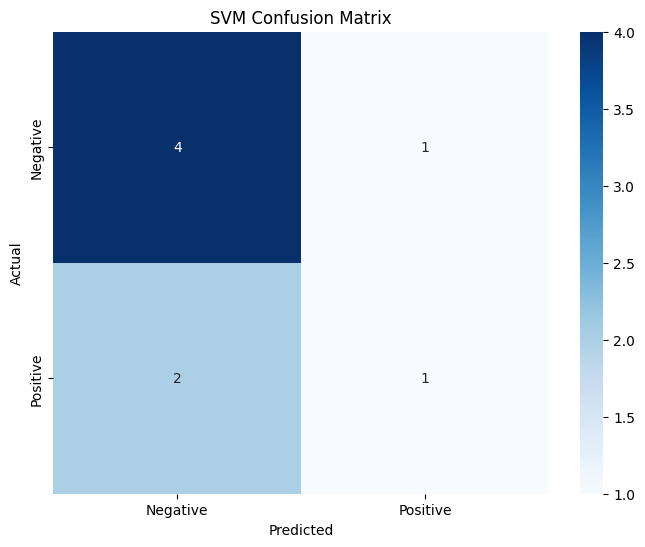

True Negatives: 4, False Positives: 1
False Negatives: 2, True Positives: 1

DETAILED BREAKDOWN OF PREDICTIONS

🔴 FALSE POSITIVES (1 samples):
Model incorrectly predicted these as POSITIVE when they were NEGATIVE:
  - 'Expect great but got disappointed'
    Actual: Negative | Predicted: Positive


🔴 FALSE NEGATIVES (2 samples):
Model incorrectly predicted these as NEGATIVE when they were POSITIVE:
  - 'Highly recommend this product'
    Actual: Positive | Predicted: Negative

  - 'I love this product so much'
    Actual: Positive | Predicted: Negative


✅ TRUE POSITIVES (1 samples):
Model correctly predicted these as POSITIVE:
  - 'Game changer absolutely love it'

✅ TRUE NEGATIVES (4 samples):
Model correctly predicted these as NEGATIVE:
  - 'Quality was really bad'
  - 'Bad decision completely regret it'
  - 'I am very unhappy with this product'


In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_bow)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

# ============ FIND SPECIFIC SAMPLES ============

# Identify indices for each category
true_negatives = np.where((y_test == 0) & (y_pred_bow == 0))[0]
false_positives = np.where((y_test == 0) & (y_pred_bow == 1))[0]
false_negatives = np.where((y_test == 1) & (y_pred_bow == 0))[0]
true_positives = np.where((y_test == 1) & (y_pred_bow == 1))[0]

print("\n" + "="*80)
print("DETAILED BREAKDOWN OF PREDICTIONS")
print("="*80)

# Show False Positives (Model predicted Positive, but actually Negative)
print(f"\n🔴 FALSE POSITIVES ({len(false_positives)} samples):")
print("Model incorrectly predicted these as POSITIVE when they were NEGATIVE:")
for idx in false_positives[:5]:  # Show first 5
    print(f"  - '{X_test[idx]}'")
    print(f"    Actual: Negative | Predicted: Positive\n")

# Show False Negatives (Model predicted Negative, but actually Positive)
print(f"\n🔴 FALSE NEGATIVES ({len(false_negatives)} samples):")
print("Model incorrectly predicted these as NEGATIVE when they were POSITIVE:")
for idx in false_negatives[:5]:  # Show first 5
    print(f"  - '{X_test[idx]}'")
    print(f"    Actual: Positive | Predicted: Negative\n")

# Show True Positives (Correctly predicted Positive)
print(f"\n✅ TRUE POSITIVES ({len(true_positives)} samples):")
print("Model correctly predicted these as POSITIVE:")
for idx in true_positives[:3]:  # Show first 3
    print(f"  - '{X_test[idx]}'")

# Show True Negatives (Correctly predicted Negative)
print(f"\n✅ TRUE NEGATIVES ({len(true_negatives)} samples):")
print("Model correctly predicted these as NEGATIVE:")
for idx in true_negatives[:3]:  # Show first 3
    print(f"  - '{X_test[idx]}'")


In [13]:
def predict_sentiment(text, show_all_models=True):
    """
    Predict sentiment using all trained models.
    """
    print(f"\nReview: '{text}'")
    print("="*80)

    # SVM with BoW
    text_bow = bow_vectorizer.transform([text])
    pred_bow = svm_bow.predict(text_bow)[0]
    print(f"SVM (BoW):        {'Positive' if pred_bow == 1 else 'Negative'}")

In [14]:
# Enter your custom review here
custom_review = "The food was bad. I ordered shawarma and tandoori, shawarma was filled with bones and tandoori had a foul smell."

# Predict sentiment using the defined function
# show_all_models is set to False to skip OpenAI calls if not configured or rate-limited
predict_sentiment(custom_review, show_all_models=False)


Review: 'The food was bad. I ordered shawarma and tandoori, shawarma was filled with bones and tandoori had a foul smell.'
SVM (BoW):        Negative


TF-IDF Feature matrix shape: (30, 20)
Number of unique features: 20

Top 100 TF-IDF features (words):
['absolutely' 'amazing' 'did' 'enemy' 'enemy gift' 'experience'
 'fantastic' 'garbage' 'gift' 'good' 'great' 'horrible' 'impressed' 'life'
 'money' 'oh' 'product' 'quality' 'really' 'worst']

SVM (TF-IDF) Accuracy: 0.6250

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.80      0.73         5
    Positive       0.50      0.33      0.40         3

    accuracy                           0.62         8
   macro avg       0.58      0.57      0.56         8
weighted avg       0.60      0.62      0.60         8



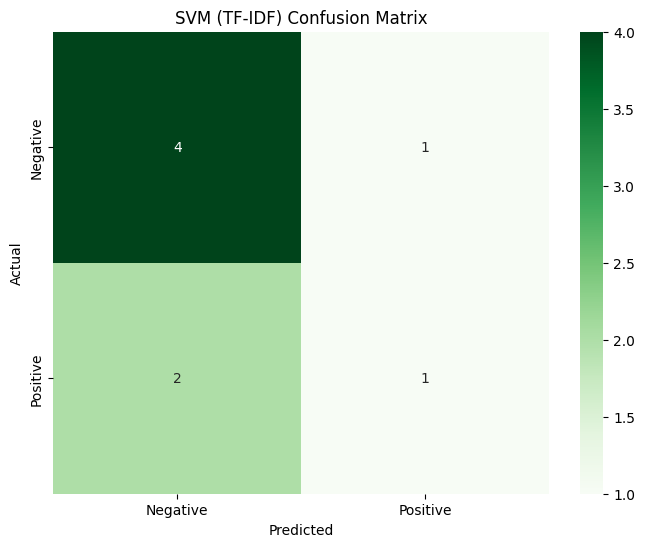


True Negatives: 4, False Positives: 1
False Negatives: 2, True Positives: 1

COMPARISON: BoW vs TF-IDF
BoW Accuracy:    0.6250
TF-IDF Accuracy: 0.6250
Difference:      0.0000


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create TF-IDF vectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization:
# This technique converts text to numerical features, giving more weight to
# important words and less weight to common words.
# TF (Term Frequency): How often a word appears in a document
# IDF (Inverse Document Frequency): How rare/important a word is across all documents
# max_features=100: Limits vocabulary to 100 most important features
# stop_words='english': Removes common English words that don't carry sentiment
# ngram_range=(1, 2): Includes both single words and word pairs
# min_df=2: Ignores words that appear in fewer than 2 documents
# max_df=0.8: Ignores words that appear in more than 80% of documents
tfidf_vectorizer = TfidfVectorizer(
    max_features=20,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

# Transform text to TF-IDF feature vectors
# fit_transform(): Learns vocabulary from training data and converts to TF-IDF vectors
# transform(): Uses learned vocabulary to convert test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of unique features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"\nTop 100 TF-IDF features (words):")
print(tfidf_vectorizer.get_feature_names_out()[:100])

# Train SVM with TF-IDF
# SVM (Support Vector Machine) Model Creation:
# SVC creates a classifier that finds the optimal boundary between sentiments
# kernel='linear': Uses linear decision boundary (works well for text)
# random_state=42: Ensures reproducible results
svm_tfidf = SVC(kernel='linear', random_state=42)

# Model Training:
# fit() trains the SVM on TF-IDF vectors and their sentiment labels
# The model learns which TF-IDF patterns indicate positive vs negative sentiment
svm_tfidf.fit(X_train_tfidf, y_train)

# Evaluate the model
# predict(): Uses trained model to predict sentiments for test data
y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)

# Accuracy Calculation:
# Compares predictions with actual labels to measure performance
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"\nSVM (TF-IDF) Accuracy: {accuracy_tfidf:.4f}")

# Classification Report:
# Shows precision, recall, F1-score for each sentiment class
# Precision: Of predicted positives/negatives, how many were correct?
# Recall: Of actual positives/negatives, how many did we find?
# F1-score: Balanced measure combining precision and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

# Generate confusion matrix
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (TF-IDF) Confusion Matrix')
plt.show()

print(f"\nTrue Negatives: {cm_tfidf[0,0]}, False Positives: {cm_tfidf[0,1]}")
print(f"False Negatives: {cm_tfidf[1,0]}, True Positives: {cm_tfidf[1,1]}")

# Compare BoW vs TF-IDF
print("\n" + "="*80)
print("COMPARISON: BoW vs TF-IDF")
print("="*80)
print(f"BoW Accuracy:    {accuracy_bow:.4f}")
print(f"TF-IDF Accuracy: {accuracy_tfidf:.4f}")
print(f"Difference:      {abs(accuracy_tfidf - accuracy_bow):.4f}")


In [17]:
def predict_sentiment(text, show_all_models=True):
    """
    Predict sentiment using all trained models (BoW and TF-IDF).
    """
    print(f"\nReview: '{text}'")
    print("="*80)

    # SVM with BoW
    # Transform input text using BoW vectorizer
    text_bow = bow_vectorizer.transform([text])
    pred_bow = svm_bow.predict(text_bow)[0]
    print(f"SVM (BoW):        {'Positive' if pred_bow == 1 else 'Negative'}")

    # SVM with TF-IDF
    # Transform input text using TF-IDF vectorizer
    text_tfidf = tfidf_vectorizer.transform([text])
    pred_tfidf = svm_tfidf.predict(text_tfidf)[0]
    print(f"SVM (TF-IDF):     {'Positive' if pred_tfidf == 1 else 'Negative'}")

# Test the function
predict_sentiment("This movie was absolutely amazing!")
predict_sentiment("Terrible waste of time and money")



Review: 'This movie was absolutely amazing!'
SVM (BoW):        Positive
SVM (TF-IDF):     Positive

Review: 'Terrible waste of time and money'
SVM (BoW):        Negative
SVM (TF-IDF):     Negative


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.5 MB/s eta 0:00:00
Sample tokenized sentence: ['absolutely', 'fantastic', 'experience']

Word2Vec vocabulary size: 88
Vector dimension: 50

Word2Vec feature matrix shape: (38, 50)
Sample sentence vector (first 10 dimensions): [ 0.00699552  0.00451641 -0.01181861 -0.00826737  0.00966315 -0.00326997
 -0.00589993  0.00145529 -0.00733959 -0.00885156]

SVM with Word2Vec - Cross-Validation Results
Accuracy: 0.6036 (+/- 0.0262)
Scores per fold: [0.625      0.625      0.625      0.57142857 0.57142857]
Min accuracy: 0.5714
Max accuracy: 0.6250

Classification Report (on full dataset):
              precision    recall  f1-score   support

    Negative       0.61      1.00      0.75        23
    Positive       0.00      0.00      0.00        15

    accuracy                           0.61        38
   macro avg       0.30      0.50      0.38        38
weighted avg       0.37      0.61      0.46        38



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


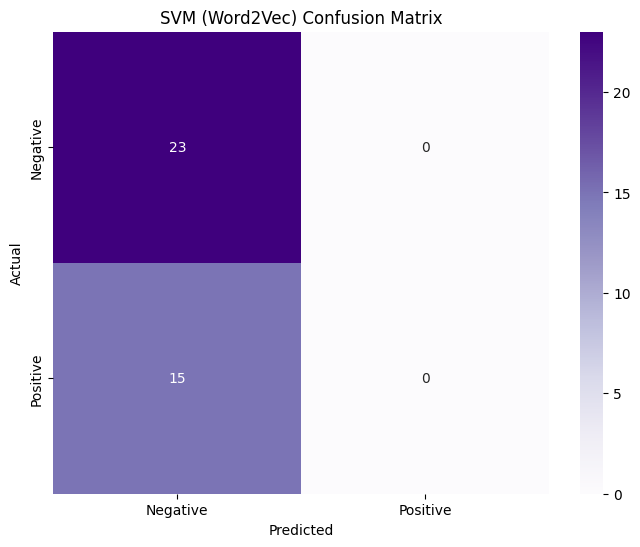


True Negatives: 23, False Positives: 0
False Negatives: 15, True Positives: 0


In [23]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Word2Vec Implementation
# Word2Vec creates dense vector representations (embeddings) for words
# Unlike BoW/TF-IDF which create sparse vectors, Word2Vec captures semantic meaning
# Words with similar meanings have similar vector representations

# Tokenize sentences for Word2Vec
# Word2Vec requires tokenized input (list of words)
# Convert each sentence to lowercase and split into words
tokenized_sentences = [sentence.lower().split() for sentence in X]

print(f"Sample tokenized sentence: {tokenized_sentences[0]}")

# Train Word2Vec model
# vector_size=50: Each word represented by 50-dimensional vector (reduced from typical 100-300 for small dataset)
# window=3: Context window - considers 3 words before and after target word
# min_count=1: Include words appearing at least once (important for small dataset)
# workers=4: Number of parallel threads for training
# sg=1: Use Skip-gram algorithm (sg=0 would be CBOW)
# epochs=100: More training iterations for small dataset
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,      # Dimension of word vectors (smaller for small dataset)
    window=3,            # Context window size
    min_count=1,         # Minimum word frequency (1 for small dataset)
    workers=4,
    sg=1,                # Skip-gram (1) or CBOW (0)
    epochs=100,          # Training iterations
    seed=42
)

print(f"\nWord2Vec vocabulary size: {len(word2vec_model.wv)}")
print(f"Vector dimension: {word2vec_model.wv.vector_size}")

# Function to convert sentence to average Word2Vec vector
def sentence_to_vec(sentence, model):
    """
    Convert a sentence to a vector by averaging word vectors.

    Process:
    1. Tokenize sentence into words
    2. Get Word2Vec vector for each word in vocabulary
    3. Average all word vectors to get sentence vector
    4. If no words found in vocabulary, return zero vector
    """
    words = sentence.lower().split()
    # Get vectors for words that exist in vocabulary
    word_vectors = [model.wv[word] for word in words if word in model.wv]

    if len(word_vectors) == 0:
        # Return zero vector if no words found
        return np.zeros(model.vector_size)

    # Average all word vectors
    return np.mean(word_vectors, axis=0)

# Convert all sentences to vectors
# Transform training and test sentences into numerical vectors
# Each sentence becomes a 50-dimensional vector (average of its word vectors)
X_word2vec = np.array([sentence_to_vec(sentence, word2vec_model) for sentence in X])

print(f"\nWord2Vec feature matrix shape: {X_word2vec.shape}")
print(f"Sample sentence vector (first 10 dimensions): {X_word2vec[0][:10]}")

# Train SVM with Word2Vec using Cross-Validation
# Cross-validation is crucial for small datasets (37 samples)
# It uses all data for both training and testing in different folds
svm_word2vec = SVC(kernel='linear', random_state=42)

# 5-Fold Cross-Validation:
# Splits data into 5 parts, trains on 4, tests on 1, repeats 5 times
# More reliable than single train/test split for small datasets
word2vec_scores = cross_val_score(svm_word2vec, X_word2vec, y_binary, cv=5, scoring='accuracy')

print("\n" + "="*80)
print("SVM with Word2Vec - Cross-Validation Results")
print("="*80)
print(f"Accuracy: {word2vec_scores.mean():.4f} (+/- {word2vec_scores.std():.4f})")
print(f"Scores per fold: {word2vec_scores}")
print(f"Min accuracy: {word2vec_scores.min():.4f}")
print(f"Max accuracy: {word2vec_scores.max():.4f}")

# Train final model on all data for predictions
svm_word2vec.fit(X_word2vec, y_binary)

# Make predictions on all data (for visualization only)
y_pred_word2vec = svm_word2vec.predict(X_word2vec)

# Classification Report
print("\nClassification Report (on full dataset):")
print(classification_report(y_binary, y_pred_word2vec, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm_word2vec = confusion_matrix(y_binary, y_pred_word2vec)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_word2vec, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (Word2Vec) Confusion Matrix')
plt.show()

print(f"\nTrue Negatives: {cm_word2vec[0,0]}, False Positives: {cm_word2vec[0,1]}")
print(f"False Negatives: {cm_word2vec[1,0]}, True Positives: {cm_word2vec[1,1]}")


COMPARISON: BoW vs TF-IDF vs Word2Vec (Cross-Validation)
BoW Accuracy:      0.6071 (+/- 0.0705)
TF-IDF Accuracy:   0.6071 (+/- 0.0705)
Word2Vec Accuracy: 0.6036 (+/- 0.0262)


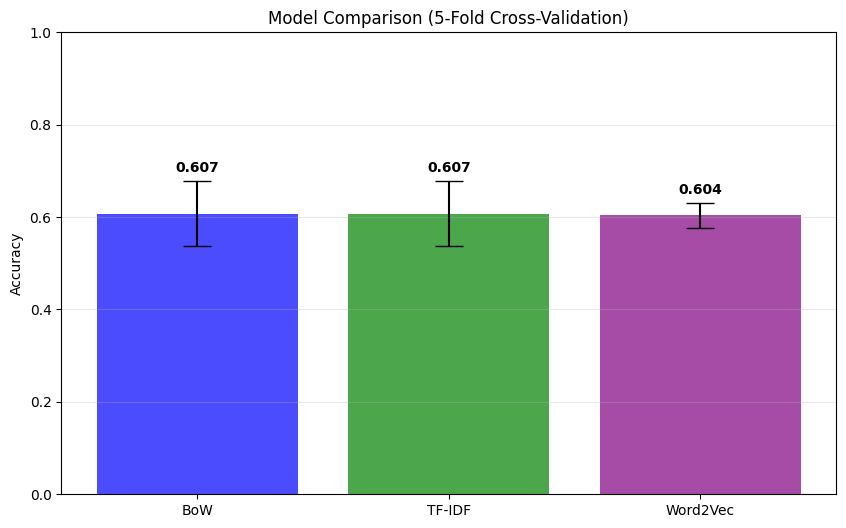

In [24]:
# Fair comparison using cross-validation for all methods
print("\n" + "="*80)
print("COMPARISON: BoW vs TF-IDF vs Word2Vec (Cross-Validation)")
print("="*80)

# BoW with reduced features
bow_vectorizer_cv = CountVectorizer(max_features=10, stop_words='english')
X_bow_cv = bow_vectorizer_cv.fit_transform(X)
svm_bow_cv = SVC(kernel='linear', random_state=42)
bow_cv_scores = cross_val_score(svm_bow_cv, X_bow_cv, y_binary, cv=5)

# TF-IDF with reduced features
tfidf_vectorizer_cv = TfidfVectorizer(max_features=10, stop_words='english')
X_tfidf_cv = tfidf_vectorizer_cv.fit_transform(X)
svm_tfidf_cv = SVC(kernel='linear', random_state=42)
tfidf_cv_scores = cross_val_score(svm_tfidf_cv, X_tfidf_cv, y_binary, cv=5)

# Results
print(f"BoW Accuracy:      {bow_cv_scores.mean():.4f} (+/- {bow_cv_scores.std():.4f})")
print(f"TF-IDF Accuracy:   {tfidf_cv_scores.mean():.4f} (+/- {tfidf_cv_scores.std():.4f})")
print(f"Word2Vec Accuracy: {word2vec_scores.mean():.4f} (+/- {word2vec_scores.std():.4f})")

# Visualization
methods = ['BoW', 'TF-IDF', 'Word2Vec']
accuracies = [bow_cv_scores.mean(), tfidf_cv_scores.mean(), word2vec_scores.mean()]
std_devs = [bow_cv_scores.std(), tfidf_cv_scores.std(), word2vec_scores.std()]

plt.figure(figsize=(10, 6))
plt.bar(methods, accuracies, yerr=std_devs, capsize=10, alpha=0.7,
        color=['blue', 'green', 'purple'])
plt.ylabel('Accuracy')
plt.title('Model Comparison (5-Fold Cross-Validation)')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, (acc, std) in enumerate(zip(accuracies, std_devs)):
    plt.text(i, acc + std + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')
plt.show()


In [25]:
# Download pre-trained GloVe embeddings (run once)
import urllib.request
import zipfile
import os

# ============================================================================
# STEP 1: Download Pre-trained GloVe Embeddings
# ============================================================================

def download_glove():
    """
    Download pre-trained GloVe embeddings (run once).
    GloVe: Global Vectors for Word Representation
    Pre-trained on Wikipedia + Gigaword corpus (6 billion tokens)
    """
    glove_dir = 'glove_embeddings'

    if not os.path.exists(glove_dir):
        os.makedirs(glove_dir)

    glove_file = f'{glove_dir}/glove.6B.50d.txt'

    if not os.path.exists(glove_file):
        print("Downloading GloVe embeddings (this may take a few minutes)...")
        url = 'http://nlp.stanford.edu/data/glove.6B.zip'
        urllib.request.urlretrieve(url, f'{glove_dir}/glove.6B.zip')

        print("Extracting files...")
        with zipfile.ZipFile(f'{glove_dir}/glove.6B.zip', 'r') as zip_ref:
            zip_ref.extractall(glove_dir)

        print("Download complete!")
    else:
        print("GloVe embeddings already downloaded.")

    return glove_file

# Download GloVe
glove_file_path = download_glove()


Extracting files...
Download complete!


In [27]:
# ============================================================================
# STEP 2: Load GloVe Embeddings
# ============================================================================

def load_glove_embeddings(file_path):
    """
    Load pre-trained GloVe word embeddings from file.

    Each line in file contains: word vector_dim1 vector_dim2 ... vector_dim50
    Returns dictionary mapping words to their 50-dimensional vectors
    """
    embeddings_index = {}

    print("Loading GloVe embeddings...")
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]  # First element is the word
            vector = np.asarray(values[1:], dtype='float32')  # Rest are vector values
            embeddings_index[word] = vector

    print(f"✓ Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

Loading GloVe embeddings...
✓ Loaded 400000 word vectors

GloVe vocabulary size: 400000
Vector dimension: 50

Sample word vectors:
  'good': [-0.35586  0.5213  -0.6107  -0.30131  0.94862]... (showing first 5 dimensions)
  'bad': [-0.17981 -0.40407 -0.1653  -0.60687 -0.39656]... (showing first 5 dimensions)
  'excellent': [-0.40431   0.78002  -0.67538  -0.097149  0.54242 ]... (showing first 5 dimensions)
  'terrible': [ 0.33209  -0.028359 -0.58145  -0.4487    0.25402 ]... (showing first 5 dimensions)

GloVe Vectorization Complete
Feature matrix shape: (38, 50)
  - Number of samples: 38
  - Vector dimension: 50

Sample sentence vector (first 10 dimensions):
  [ 0.35191667  0.16203333 -0.5673967   0.11606     0.6813433  -0.207736
  0.01138001  0.14816667  0.025607    0.64488333]

Training SVM with GloVe Embeddings
Cross-Validation Results:
  Accuracy: 0.8929 (+/- 0.0542)
  Scores per fold: [0.875      0.875      1.         0.85714286 0.85714286]
  Min accuracy: 0.8571
  Max accuracy: 1.00

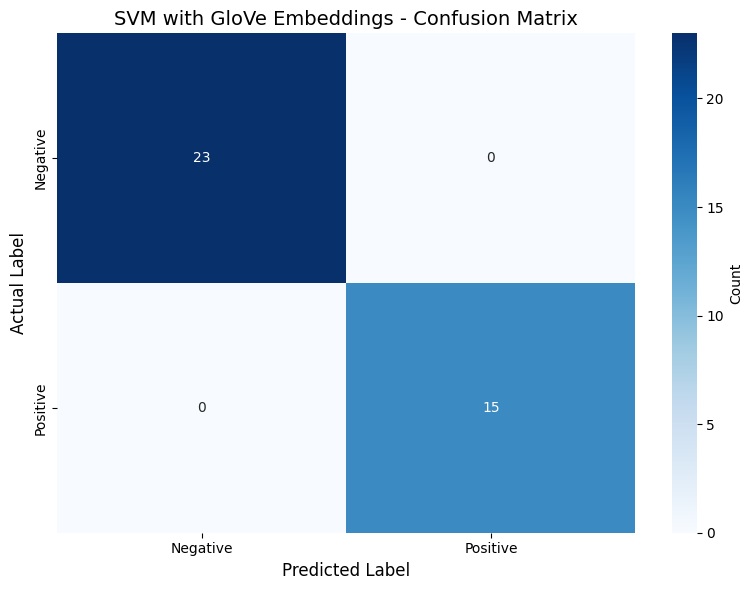


Testing Predictions

Review: 'This movie was absolutely amazing and wonderful!'
Predicted Sentiment: Positive

Review: 'Terrible waste of time and money'
Predicted Sentiment: Negative

Review: 'The film was okay, nothing special'
Predicted Sentiment: Positive

Review: 'I loved every minute of it, highly recommend!'
Predicted Sentiment: Positive

Review: 'Boring and disappointing, would not watch again'
Predicted Sentiment: Negative

Comparison with Other Methods
BoW            : 0.6071 (+/- 0.0705)
TF-IDF         : 0.6071 (+/- 0.0705)
Word2Vec       : 0.6036 (+/- 0.0262)
GloVe          : 0.8929 (+/- 0.0542)


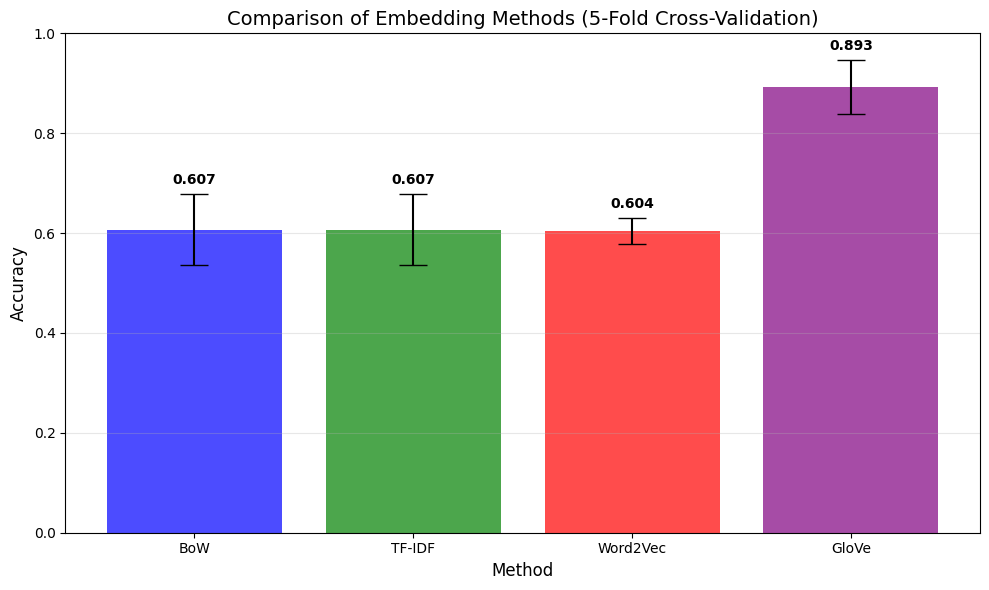


🏆 Best Method: GloVe with 0.8929 accuracy


In [28]:
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load GloVe embeddings (50-dimensional vectors)
glove_embeddings = load_glove_embeddings(glove_file_path)

# Check vocabulary
print(f"\nGloVe vocabulary size: {len(glove_embeddings)}")
print(f"Vector dimension: {len(glove_embeddings['good'])}")

# Test some words
print("\nSample word vectors:")
for word in ['good', 'bad', 'excellent', 'terrible']:
    if word in glove_embeddings:
        print(f"  '{word}': {glove_embeddings[word][:5]}... (showing first 5 dimensions)")


In [ ]:
# ============================================================================
# STEP 3: Convert Sentences to Vectors (Simple Averaging)
# ============================================================================

def sentence_to_glove_vector(sentence, embeddings_dict, embedding_dim=50):
    """
    Convert a sentence to a vector using GloVe embeddings.

    Method: SIMPLE AVERAGING (Most Common Approach)
    1. Split sentence into words
    2. Look up each word in GloVe vocabulary
    3. Average all word vectors to create sentence vector

    Args:
        sentence: Input text string
        embeddings_dict: Dictionary of word -> vector mappings
        embedding_dim: Dimension of word vectors (default 50)

    Returns:
        50-dimensional numpy array representing the sentence
    """
    # Tokenize and lowercase
    words = sentence.lower().split()

    # Collect vectors for words that exist in GloVe vocabulary
    word_vectors = []
    for word in words:
        if word in embeddings_dict:
            word_vectors.append(embeddings_dict[word])

    # Handle case where no words found in vocabulary
    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)

    # Return average of all word vectors
    return np.mean(word_vectors, axis=0)

In [ ]:
# ============================================================================
# STEP 4: Transform All Sentences to GloVe Vectors
# ============================================================================

# Convert all sentences in dataset to GloVe vectors
X_glove = np.array([sentence_to_glove_vector(sentence, glove_embeddings)
                    for sentence in X])

print("\n" + "="*80)
print("GloVe Vectorization Complete")
print("="*80)
print(f"Feature matrix shape: {X_glove.shape}")
print(f"  - Number of samples: {X_glove.shape[0]}")
print(f"  - Vector dimension: {X_glove.shape[1]}")
print(f"\nSample sentence vector (first 10 dimensions):")
print(f"  {X_glove[0][:10]}")

In [ ]:
# ============================================================================
# STEP 5: Train SVM Classifier with GloVe Features
# ============================================================================

# Train SVM using Cross-Validation (better for small datasets)
# Cross-validation splits data into 5 folds, trains on 4, tests on 1
# Repeats 5 times to use all data for both training and testing
svm_glove = SVC(kernel='linear', random_state=42)

print("\n" + "="*80)
print("Training SVM with GloVe Embeddings")
print("="*80)

# 5-Fold Cross-Validation
glove_scores = cross_val_score(svm_glove, X_glove, y_binary, cv=5, scoring='accuracy')

print(f"Cross-Validation Results:")
print(f"  Accuracy: {glove_scores.mean():.4f} (+/- {glove_scores.std():.4f})")
print(f"  Scores per fold: {glove_scores}")
print(f"  Min accuracy: {glove_scores.min():.4f}")
print(f"  Max accuracy: {glove_scores.max():.4f}")

In [ ]:
# ============================================================================
# STEP 6: Train Final Model on Full Dataset
# ============================================================================

# Train on all data for making predictions
svm_glove.fit(X_glove, y_binary)

# Make predictions
y_pred_glove = svm_glove.predict(X_glove)


In [ ]:
# ============================================================================
# STEP 7: Evaluation Metrics
# ============================================================================

print("\n" + "="*80)
print("Classification Report")
print("="*80)
print(classification_report(y_binary, y_pred_glove, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm_glove = confusion_matrix(y_binary, y_pred_glove)

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {cm_glove[0,0]}")
print(f"  False Positives: {cm_glove[0,1]}")
print(f"  False Negatives: {cm_glove[1,0]}")
print(f"  True Positives:  {cm_glove[1,1]}")

In [ ]:
# ============================================================================
# STEP 8: Visualize Confusion Matrix
# ============================================================================

plt.figure(figsize=(8, 6))
sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('SVM with GloVe Embeddings - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# STEP 9: Prediction Function
# ============================================================================

def predict_sentiment_glove(text):
    """
    Predict sentiment of new text using trained GloVe model.

    Args:
        text: Input sentence/review

    Returns:
        Predicted sentiment (Positive/Negative)
    """
    # Convert text to GloVe vector
    text_vector = sentence_to_glove_vector(text, glove_embeddings).reshape(1, -1)

    # Predict
    prediction = svm_glove.predict(text_vector)[0]
    sentiment = 'Positive' if prediction == 1 else 'Negative'

    print(f"\nReview: '{text}'")
    print(f"Predicted Sentiment: {sentiment}")

    return sentiment

In [ ]:
# ============================================================================
# STEP 10: Test Predictions
# ============================================================================

print("\n" + "="*80)
print("Testing Predictions")
print("="*80)

# Test with sample sentences
predict_sentiment_glove("This movie was absolutely amazing and wonderful!")
predict_sentiment_glove("Terrible waste of time and money")
predict_sentiment_glove("The film was okay, nothing special")
predict_sentiment_glove("I loved every minute of it, highly recommend!")
predict_sentiment_glove("Boring and disappointing, would not watch again")


In [ ]:
# ============================================================================
# STEP 11: Compare with Other Methods
# ============================================================================

print("\n" + "="*80)
print("Comparison with Other Methods")
print("="*80)

# Assuming you have BoW, TF-IDF, and Word2Vec already trained
methods = ['BoW', 'TF-IDF', 'Word2Vec', 'GloVe']
accuracies = [
    bow_cv_scores.mean(),
    tfidf_cv_scores.mean(),
    word2vec_scores.mean(),
    glove_scores.mean()
]
std_devs = [
    bow_cv_scores.std(),
    tfidf_cv_scores.std(),
    word2vec_scores.std(),
    glove_scores.std()
]

# Print comparison
for method, acc, std in zip(methods, accuracies, std_devs):
    print(f"{method:15s}: {acc:.4f} (+/- {std:.4f})")

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, yerr=std_devs, capsize=10,
               alpha=0.7, color=['blue', 'green', 'red', 'purple'])
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.title('Comparison of Embedding Methods (5-Fold Cross-Validation)', fontsize=14)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (acc, std) in enumerate(zip(accuracies, std_devs)):
    plt.text(i, acc + std + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Find best method
best_idx = np.argmax(accuracies)
print(f"\n🏆 Best Method: {methods[best_idx]} with {accuracies[best_idx]:.4f} accuracy")